# Analyse Exploratoire — CESNET-TimeSeries24

## Objectif
Explorer et comprendre le dataset CESNET-TimeSeries24 pour préparer les données à l'entraînement de l'Autoencoder.

## Dataset
- Source : Zenodo (zenodo.org/records/13382427)
- Fichiers : ip_addresses_sample, times, ids_relationship
- Features : 12 features de flux réseau par fenêtre de 10 minutes

1. Charger les données
On a pris 50 fichiers CSV (50 adresses IP) et on les a combinés → 952 697 lignes

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

# Chemin vers les données
data_path = Path("../data/ip_addresses_sample/agg_10_minutes")

# Charger quelques fichiers CSV
files = list(data_path.glob("*.csv"))
print(f"Nombre de fichiers : {len(files)}")
print(f"Premier fichier : {files[0].name}")

# Charger le premier fichier
df_sample = pd.read_csv(files[0])
print(f"\nShape : {df_sample.shape}")
print(f"\nColonnes : {list(df_sample.columns)}")
df_sample.head()

Nombre de fichiers : 1000
Premier fichier : 100610.csv

Shape : (38229, 13)

Colonnes : ['id_time', 'n_flows', 'n_packets', 'n_bytes', 'n_dest_asn', 'n_dest_ports', 'n_dest_ip', 'tcp_udp_ratio_packets', 'tcp_udp_ratio_bytes', 'dir_ratio_packets', 'dir_ratio_bytes', 'avg_duration', 'avg_ttl']


,id_time,n_flows,n_packets,n_bytes,n_dest_asn,n_dest_ports,n_dest_ip,tcp_udp_ratio_packets,tcp_udp_ratio_bytes,dir_ratio_packets,dir_ratio_bytes,avg_duration,avg_ttl
0,0,14,96,11462,12.0,13.0,12.0,1.00,1.00,0.51,0.54,3.84,177.36
1,1,14,53,6413,11.0,12.0,12.0,0.87,0.87,0.51,0.55,0.78,109.57
2,2,15,96,12698,11.0,12.0,12.0,0.91,0.94,0.44,0.46,1.85,80.80
3,3,9,59,7822,7.0,9.0,9.0,0.90,0.93,0.59,0.67,1.45,74.56
4,4,16,75,9862,9.0,14.0,13.0,0.99,0.99,0.63,0.73,0.97,128.31


2. Vérifier la qualité
Zéro valeurs manquantes → données propres dès le départ

In [3]:
# Charger 50 fichiers pour avoir assez de données sans surcharger la RAM
dfs = []
for f in files[:50]:
    df_temp = pd.read_csv(f)
    df_temp['ip_id'] = f.stem  # ajouter l'ID de l'IP
    dfs.append(df_temp)

# Combiner tous les DataFrames
df = pd.concat(dfs, ignore_index=True)
print(f"Shape total : {df.shape}")
print(f"\nValeurs manquantes :\n{df.isnull().sum()}")

Shape total : (952697, 14)

Valeurs manquantes :
id_time                  0
n_flows                  0
n_packets                0
n_bytes                  0
n_dest_asn               0
n_dest_ports             0
n_dest_ip                0
tcp_udp_ratio_packets    0
tcp_udp_ratio_bytes      0
dir_ratio_packets        0
dir_ratio_bytes          0
avg_duration             0
avg_ttl                  0
ip_id                    0
dtype: int64


3. Regarder les distributions
On a vu que n_flows, n_packets, n_bytes sont très skewed — la plupart des IPs ont peu de trafic mais quelques-unes ont énormément. C'est normal sur un vrai réseau.

In [4]:
# Statistiques descriptives
df.describe().round(2)

,id_time,n_flows,n_packets,n_bytes,n_dest_asn,n_dest_ports,n_dest_ip,tcp_udp_ratio_packets,tcp_udp_ratio_bytes,dir_ratio_packets,dir_ratio_bytes,avg_duration,avg_ttl
count,952697.00,952697.00,952697.00,9.526970e+05,952697.00,952697.00,952697.00,952697.00,952697.00,952697.00,952697.00,952697.00,952697.00
mean,19164.97,1438.43,66690.54,6.760377e+07,93.17,837.98,960.29,0.66,0.67,0.46,0.42,20.24,123.67
std,11607.48,5857.92,252642.20,2.822065e+08,303.37,3830.66,4110.42,0.38,0.39,0.20,0.28,32.34,55.70
min,0.00,1.00,1.00,2.800000e+01,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,6.00
25%,8808.00,8.00,29.00,2.676000e+03,4.00,4.00,6.00,0.29,0.27,0.33,0.18,1.19,80.71
50%,18923.00,23.00,177.00,3.300000e+04,7.00,6.00,14.00,0.86,0.90,0.46,0.42,6.98,109.00
75%,28896.00,149.00,2032.00,1.035374e+06,25.00,15.00,93.00,0.99,1.00,0.55,0.57,26.19,154.14
max,40297.00,88603.00,30344628.00,4.256080e+10,2130.00,48624.00,36814.00,1.00,1.00,1.00,1.00,299.99,255.00


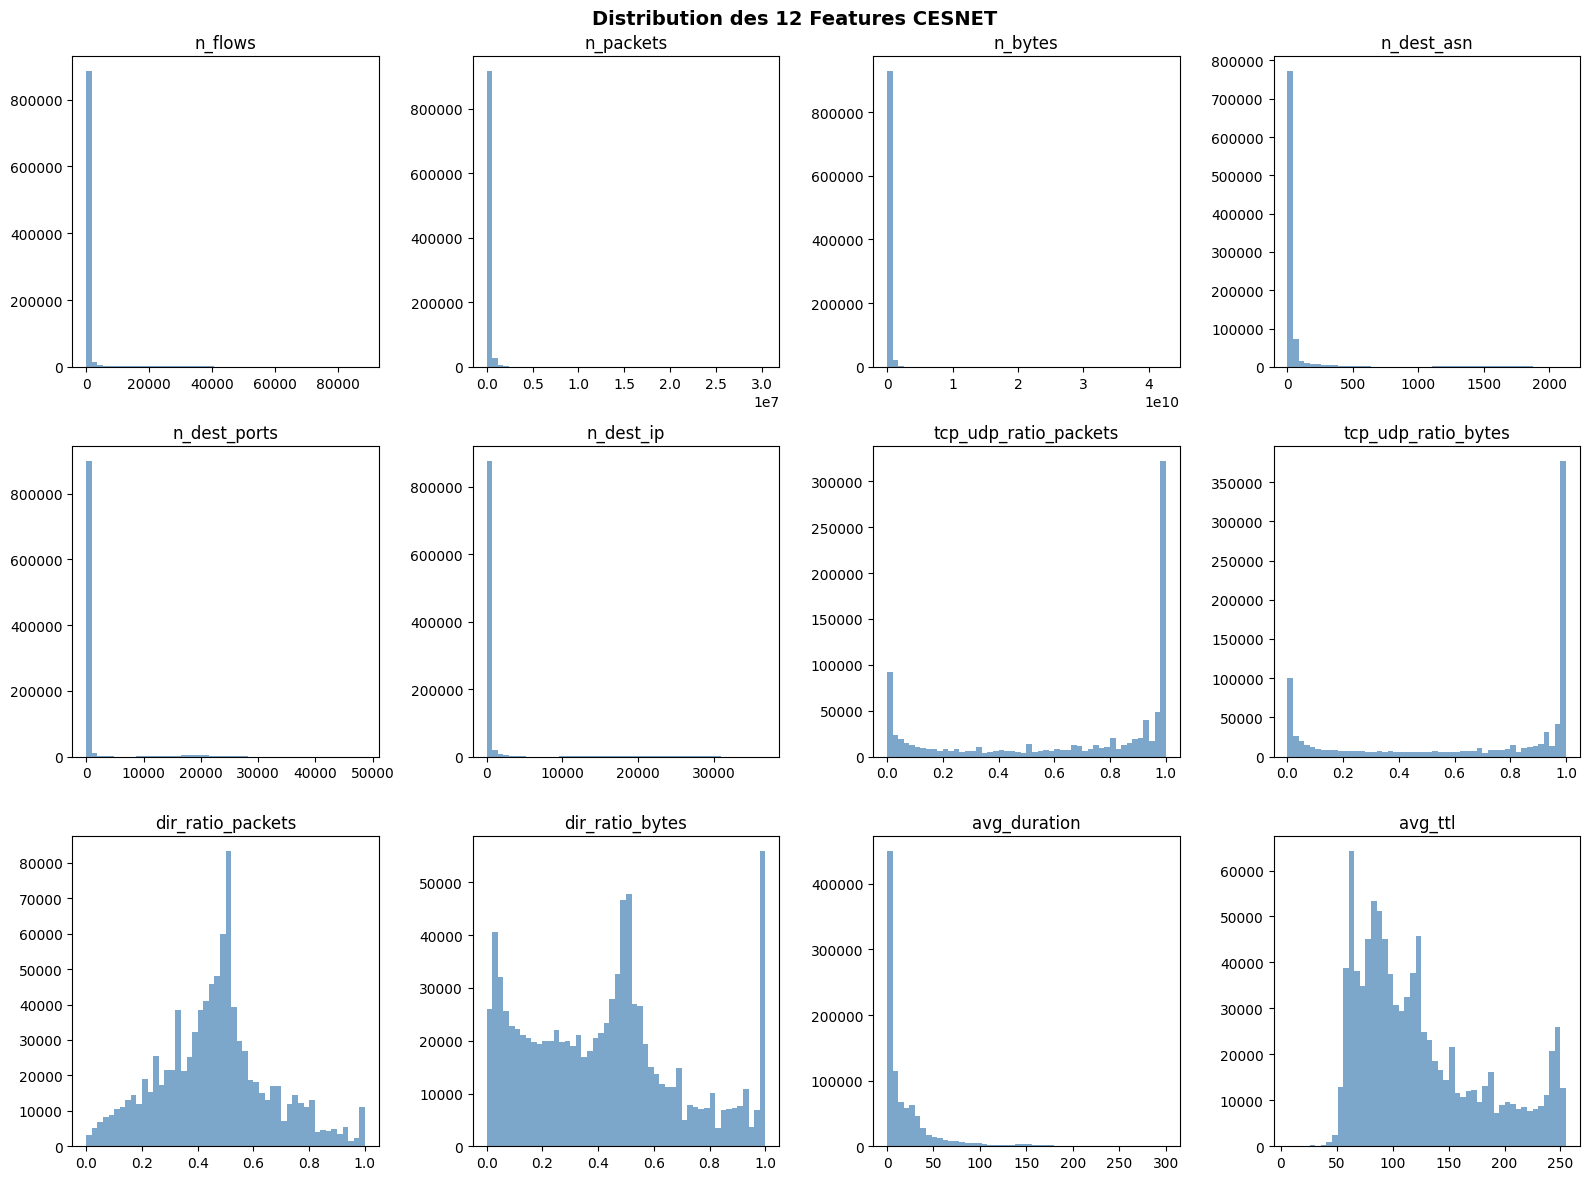

Graphique sauvegardé 


In [5]:
# Distribution des features principales
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

features = ['n_flows', 'n_packets', 'n_bytes', 'n_dest_asn', 
            'n_dest_ports', 'n_dest_ip', 'tcp_udp_ratio_packets',
            'tcp_udp_ratio_bytes', 'dir_ratio_packets', 'dir_ratio_bytes',
            'avg_duration', 'avg_ttl']

for i, col in enumerate(features):
    axes[i].hist(df[col], bins=50, color='steelblue', alpha=0.7)
    axes[i].set_title(col)
    axes[i].set_xlabel('')

plt.suptitle('Distribution des 12 Features CESNET', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../notes/distributions.png', dpi=100, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé ")

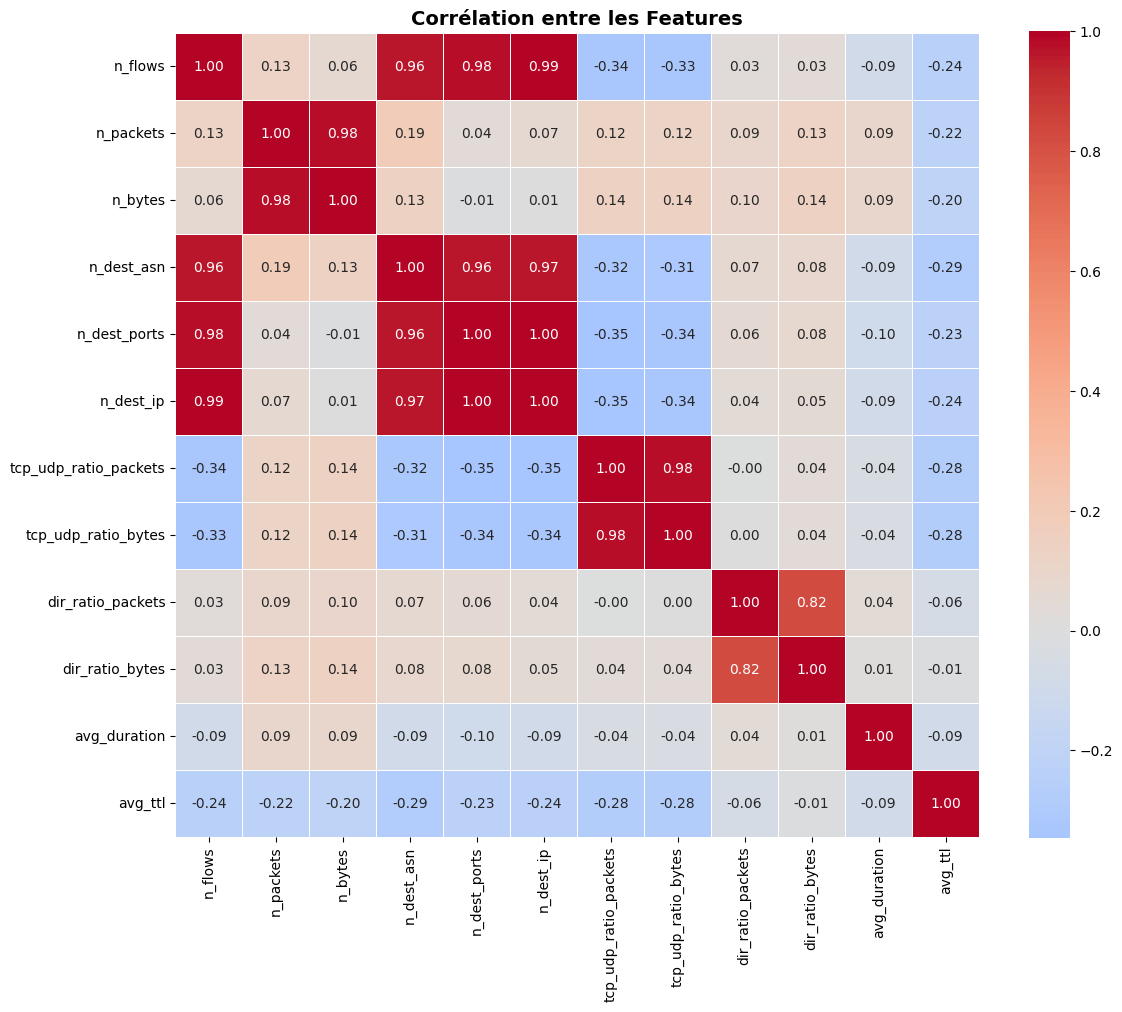

Heatmap sauvegardée 


In [6]:
# Heatmap de corrélation
plt.figure(figsize=(12, 10))
corr = df[features].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5)
plt.title('Corrélation entre les Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../notes/correlation.png', dpi=100, bbox_inches='tight')
plt.show()
print("Heatmap sauvegardée ")

4. Log transform
Pour les features skewed on a appliqué log1p(x) — ça "compresse" les grandes valeurs pour que le modèle les traite mieux.

5. StandardScaler
On a normalisé toutes les features entre -2 et +4 — pour que le modèle ne favorise pas une feature par rapport à une autre.

6. Train/Test split
80% pour entraîner l'Autoencoder, 20% pour tester.

In [8]:
from sklearn.preprocessing import StandardScaler
import joblib

# Features à utiliser
features = ['n_flows', 'n_packets', 'n_bytes', 'n_dest_asn', 
            'n_dest_ports', 'n_dest_ip', 'tcp_udp_ratio_packets',
            'tcp_udp_ratio_bytes', 'dir_ratio_packets', 'dir_ratio_bytes',
            'avg_duration', 'avg_ttl']

# Log transform sur les features skewed
skewed = ['n_flows', 'n_packets', 'n_bytes', 'n_dest_asn', 
          'n_dest_ports', 'n_dest_ip', 'avg_duration']

df_processed = df.copy()
for col in skewed:
    df_processed[col] = np.log1p(df_processed[col])

# StandardScaler
X = df_processed[features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/Test split (80/20)
split = int(0.8 * len(X_scaled))
X_train = X_scaled[:split]
X_test = X_scaled[split:]

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")

# Sauvegarder
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(X_train, '../data/X_train.pkl')
joblib.dump(X_test, '../data/X_test.pkl')
print("\nTout sauvegardé ")

X_train : (762157, 12)
X_test  : (190540, 12)

Tout sauvegardé 


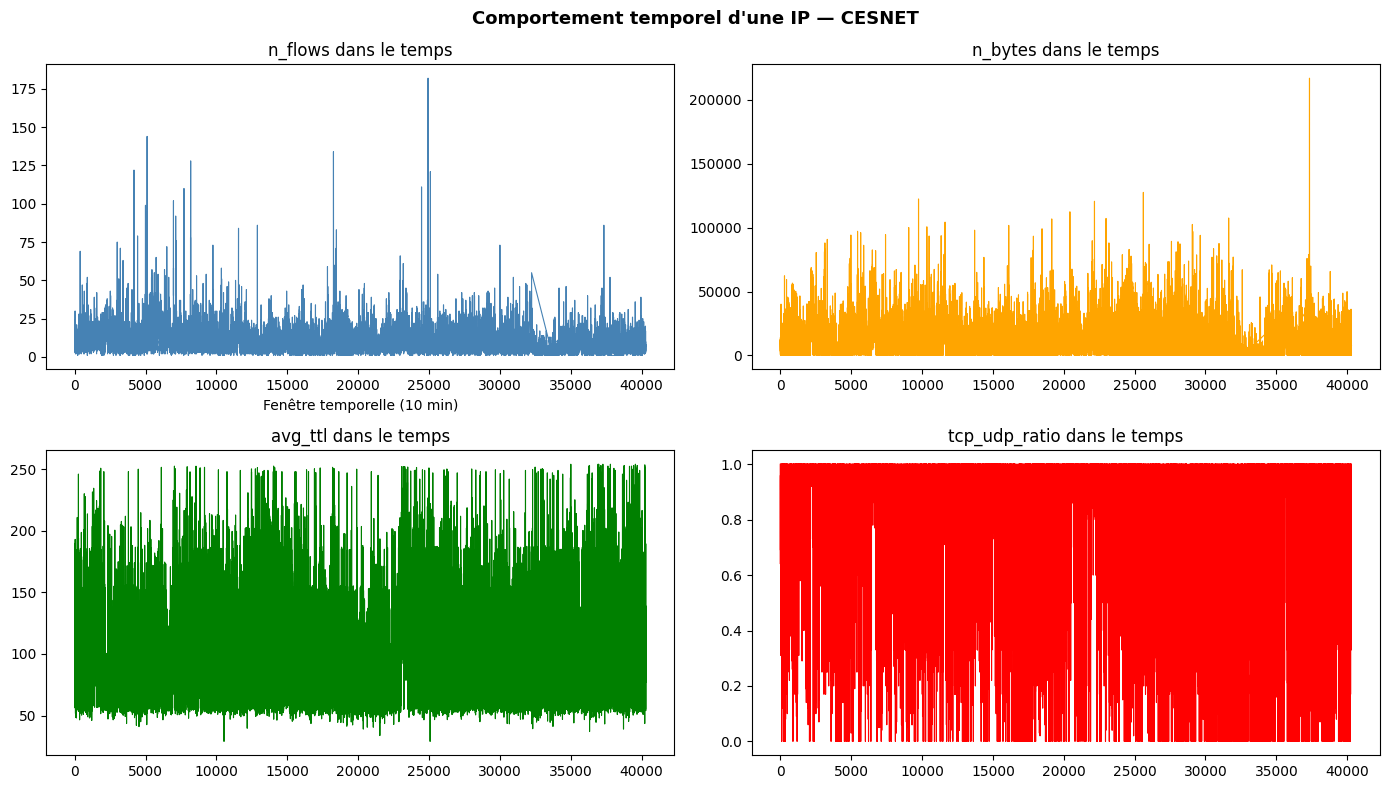

Graphique sauvegardé 


In [9]:
# Visualiser une série temporelle d'une IP
ip_sample = df[df['ip_id'] == df['ip_id'].unique()[0]]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0,0].plot(ip_sample['id_time'], ip_sample['n_flows'], color='steelblue', linewidth=0.8)
axes[0,0].set_title('n_flows dans le temps')
axes[0,0].set_xlabel('Fenêtre temporelle (10 min)')

axes[0,1].plot(ip_sample['id_time'], ip_sample['n_bytes'], color='orange', linewidth=0.8)
axes[0,1].set_title('n_bytes dans le temps')

axes[1,0].plot(ip_sample['id_time'], ip_sample['avg_ttl'], color='green', linewidth=0.8)
axes[1,0].set_title('avg_ttl dans le temps')

axes[1,1].plot(ip_sample['id_time'], ip_sample['tcp_udp_ratio_packets'], color='red', linewidth=0.8)
axes[1,1].set_title('tcp_udp_ratio dans le temps')

plt.suptitle('Comportement temporel d\'une IP — CESNET', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../notes/timeseries.png', dpi=100, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé ")

In [10]:
# Sauvegarder le DataFrame combiné
df.to_csv('../data/cesnet_sample.csv', index=False)
print(f"Sauvegardé : {df.shape[0]} lignes, {df.shape[1]} colonnes dans 'cesnet_sample.csv'")

Sauvegardé : 952697 lignes, 14 colonnes dans 'cesnet_sample.csv'


In [2]:
import joblib
import numpy as np

# Charger les données
X_train = joblib.load('../data/X_train.pkl')
X_test = joblib.load('../data/X_test.pkl')
scaler = joblib.load('../models/scaler.pkl')

print(f"X_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"\nX_train — min : {X_train.min():.3f}, max : {X_train.max():.3f}, mean : {X_train.mean():.3f}")
print(f"X_test  — min : {X_test.min():.3f}, max : {X_test.max():.3f}, mean : {X_test.mean():.3f}")
print("\nDonnées prêtes pour l'Autoencoder ")

X_train shape : (762157, 12)
X_test shape  : (190540, 12)

X_train — min : -2.314, max : 4.151, mean : 0.061
X_test  — min : -2.314, max : 2.748, mean : -0.245

Données prêtes pour l'Autoencoder 
